In [ ]:
# !pip install --upgrade google-meridian[colab,and-cuda,schema] --no-cache-dir --force-reinstall

In [ ]:
import IPython
from meridian import constants
from meridian.analysis import analyzer
from meridian.analysis import optimizer
from meridian.analysis import summarizer
from meridian.analysis import visualizer
from meridian.analysis.review import reviewer
from meridian.data import data_frame_input_data_builder
from meridian.model import model
from meridian.model import prior_distribution
from meridian.model import spec
from meridian.schema.serde import meridian_serde


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import plotly.express as px

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import seasonal_decompose



# check if GPU is available
from psutil import virtual_memory
import tensorflow as tf
import tensorflow_probability as tfp

# Set the default float type for TensorFlow to float64 to prevent type mismatch errors
tf.keras.backend.set_floatx('float32')

ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))
print(
    'Num GPUs Available: ',
    len(tf.config.experimental.list_physical_devices('GPU')),
)
print(
    'Num CPUs Available: ',
    len(tf.config.experimental.list_physical_devices('CPU')),
)

Your runtime has 13.6 gigabytes of available RAM

Num GPUs Available:  0
Num CPUs Available:  1


In [ ]:
df = pd.read_csv('MMM_V2.csv')

df.head()

,DATE,COUNTRY,REVENUE_NET_USD_TOTAL,AD_COST_USD_CRITEO_PROSPECTING,AD_COST_USD_CRITEO_REMARKETING,AD_COST_USD_EMAIL,AD_COST_USD_FACEBOOK_ASC,AD_COST_USD_FACEBOOK_PROSP,AD_COST_USD_FACEBOOK_REMARKETING,AD_COST_USD_FACEBOOK_RETENTION,...,AD_IMPRESSIONS_FACEBOOK_ASC,AD_IMPRESSIONS_FACEBOOK_PROSP,AD_CLICKS_FACEBOOK_REMARKETING,AD_CLICKS_FACEBOOK_RETENTION,AD_CLICKS_GOOGLE_REMARKETING,AD_CLICKS_SEARCH_BRAND,AD_IMPRESSIONS_SEARCH_NON_BRAND,AD_IMPRESSIONS_SEARCH_PMAX,AD_IMPRESSIONS_SEARCH_SHOPPING,SESSIONS_ORGANIC
0,2022-07-01,US,387224,511,1389,1292,0,473,0,0,...,0,42336,0,0,0,2724,315910,0,390076,16362
1,2022-07-02,US,64608,0,772,338,0,478,0,0,...,0,42448,0,0,119178,910,188754,0,203740,3890
2,2022-07-03,US,49517,898,503,254,0,506,0,0,...,0,51184,0,0,0,734,184404,0,182148,2888
3,2022-07-04,US,75814,1438,609,260,0,0,0,0,...,0,0,0,0,0,900,188606,0,333092,4524
4,2022-07-05,US,407333,1436,1826,1234,0,0,0,0,...,0,0,0,0,204132,3540,314046,0,656754,18544


In [ ]:
df.columns

Index(['DATE', 'COUNTRY', 'REVENUE_NET_USD_TOTAL',
       'AD_COST_USD_CRITEO_PROSPECTING', 'AD_COST_USD_CRITEO_REMARKETING',
       'AD_COST_USD_EMAIL', 'AD_COST_USD_FACEBOOK_ASC',
       'AD_COST_USD_FACEBOOK_PROSP', 'AD_COST_USD_FACEBOOK_REMARKETING',
       'AD_COST_USD_FACEBOOK_RETENTION', 'AD_COST_USD_GOOGLE_REMARKETING',
       'AD_COST_USD_PAID_DISPLAY', 'AD_COST_USD_SEARCH_BRAND',
       'AD_COST_USD_SEARCH_NON_BRAND', 'AD_COST_USD_SEARCH_PMAX',
       'AD_COST_USD_SEARCH_SHOPPING', 'AD_IMPRESSIONS_CRITEO_PROSPECTING',
       'AD_IMPRESSIONS_CRITEO_REMARKETING', 'EMAIL_OPEN',
       'AD_IMPRESSIONS_FACEBOOK_ASC', 'AD_IMPRESSIONS_FACEBOOK_PROSP',
       'AD_CLICKS_FACEBOOK_REMARKETING', 'AD_CLICKS_FACEBOOK_RETENTION',
       'AD_CLICKS_GOOGLE_REMARKETING', 'AD_CLICKS_SEARCH_BRAND',
       'AD_IMPRESSIONS_SEARCH_NON_BRAND', 'AD_IMPRESSIONS_SEARCH_PMAX',
       'AD_IMPRESSIONS_SEARCH_SHOPPING', 'SESSIONS_ORGANIC'],
      dtype='object')

### EDA

In [ ]:
# Agg the data at a week level

df['DATE'] = pd.to_datetime(df['DATE'])

weekly_df = (
    df
    .groupby(pd.Grouper(key='DATE', freq='W-MON'))  # Week starting Monday
    .sum(numeric_only=True)
    .reset_index()
)

488.33228


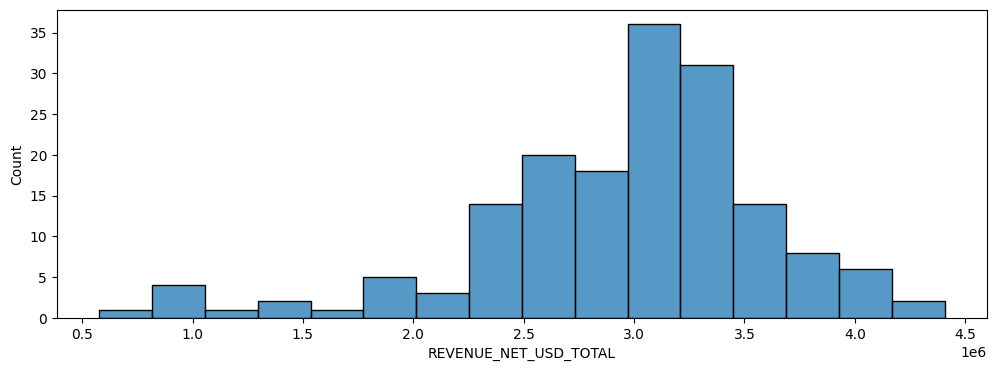

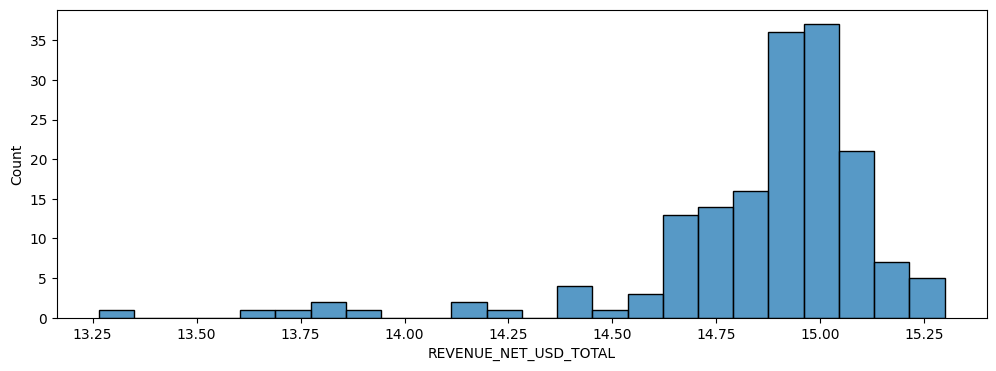

In [ ]:
#total revenue
print(weekly_df['REVENUE_NET_USD_TOTAL'].sum()/1000000)


#check the revenue distribution

plt.figure(figsize=(12, 4))
sns.histplot(weekly_df['REVENUE_NET_USD_TOTAL'])
plt.show()


#log transform view
plt.figure(figsize=(12, 4))
sns.histplot(np.log1p(weekly_df['REVENUE_NET_USD_TOTAL']))
plt.show()

In [ ]:
#Revenue by time
fig = go.Figure()
fig.add_trace( go.Scatter(x=weekly_df['DATE'],y=weekly_df['REVENUE_NET_USD_TOTAL'],mode='lines',name='Revenue'))
fig.show()

### the lower points are coming from off season months. we will have to add control flags to represent this

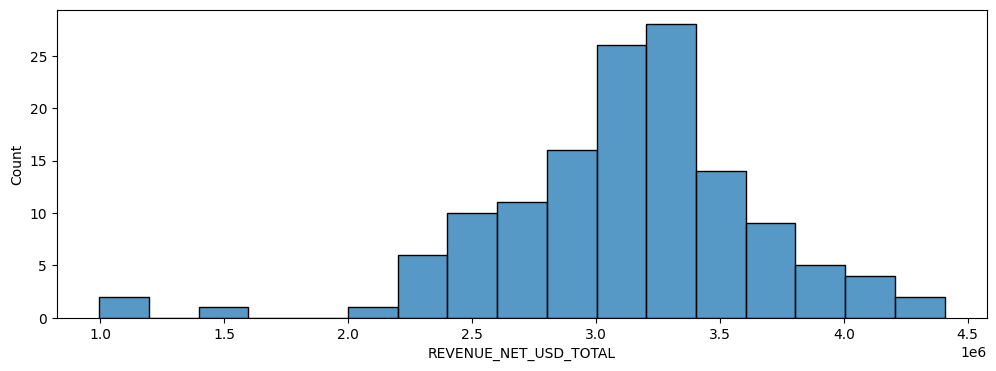

In [ ]:
weekly_df_test = weekly_df

weekly_df_test['MONTH'] = weekly_df_test['DATE'].dt.month

weekly_df_test = weekly_df_test[(weekly_df_test['MONTH']!=12) & (weekly_df_test['MONTH']!=7)]


#check the revenue distribution

plt.figure(figsize=(12, 4))
sns.histplot(weekly_df_test['REVENUE_NET_USD_TOTAL'])
plt.show()

In [ ]:
# List the start dates of the weeks with steep drops
off_season_dates = [
    '2022-12-26',
    '2023-07-03',
    '2023-12-25',
    '2024-07-08',
    '2024-12-30',
    '2024-07-07'
    # Add any other specific dates you identified here
]

# Create the binary flag (1 if in the list, 0 otherwise)
weekly_df['is_off_season'] = weekly_df['DATE'].isin(pd.to_datetime(off_season_dates)).astype(int)
weekly_df.head()

,DATE,REVENUE_NET_USD_TOTAL,AD_COST_USD_CRITEO_PROSPECTING,AD_COST_USD_CRITEO_REMARKETING,AD_COST_USD_EMAIL,AD_COST_USD_FACEBOOK_ASC,AD_COST_USD_FACEBOOK_PROSP,AD_COST_USD_FACEBOOK_REMARKETING,AD_COST_USD_FACEBOOK_RETENTION,AD_COST_USD_GOOGLE_REMARKETING,...,AD_CLICKS_FACEBOOK_REMARKETING,AD_CLICKS_FACEBOOK_RETENTION,AD_CLICKS_GOOGLE_REMARKETING,AD_CLICKS_SEARCH_BRAND,AD_IMPRESSIONS_SEARCH_NON_BRAND,AD_IMPRESSIONS_SEARCH_PMAX,AD_IMPRESSIONS_SEARCH_SHOPPING,SESSIONS_ORGANIC,MONTH,is_off_season
0,2022-07-04,577163,2847,3273,2144,0,1457,0,0,2063,...,0,0,119178,5268,877674,0,1109056,27664,7,0
1,2022-07-11,2285216,5447,15632,7642,0,2402,0,0,0,...,0,0,296043,18644,1607870,0,1154548,84296,7,0
2,2022-07-18,2316998,4634,10819,7642,0,3359,0,0,478,...,0,0,482608,19304,2004880,0,4632120,82842,7,0
3,2022-07-25,2395253,2444,1765,7642,0,4804,0,0,0,...,0,0,0,19414,1915990,0,4496322,51296,7,0
4,2022-08-01,2401224,3406,5590,8200,0,4914,0,0,0,...,0,0,0,17522,2006630,0,3151168,41742,8,0


<Axes: xlabel='DATE', ylabel='AD_COST_USD_PAID_SOCIAL'>

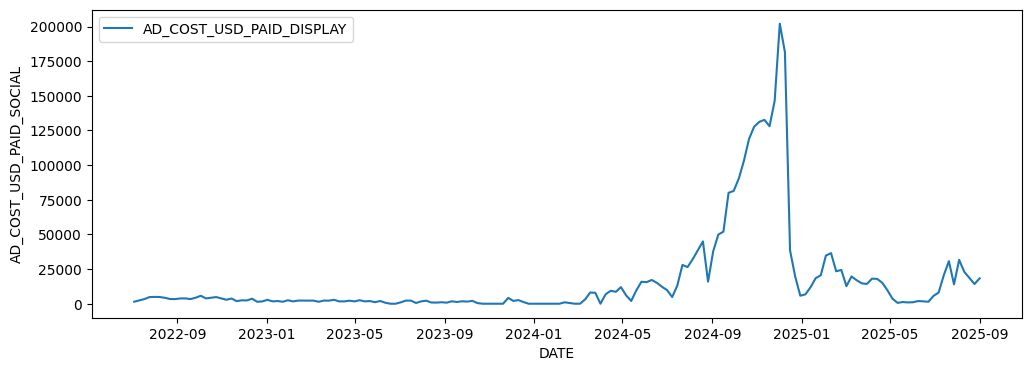

In [ ]:

# All Criteo channels should be grouped as display

weekly_df['AD_COST_USD_PAID_DISPLAY'] = weekly_df['AD_COST_USD_CRITEO_PROSPECTING'] + weekly_df['AD_COST_USD_CRITEO_REMARKETING']
weekly_df['AD_IMPRESSIONS_USD_PAID_DISPLAY'] = weekly_df['AD_IMPRESSIONS_CRITEO_PROSPECTING'] + weekly_df['AD_IMPRESSIONS_CRITEO_REMARKETING']

# all fb spends under Social
weekly_df['AD_COST_USD_PAID_SOCIAL'] = weekly_df['AD_COST_USD_FACEBOOK_PROSP'] + weekly_df['AD_COST_USD_FACEBOOK_REMARKETING']
weekly_df['AD_IMPRESSIONS_PAID_SOCIAL'] = weekly_df['AD_IMPRESSIONS_FACEBOOK_PROSP'] + weekly_df['AD_CLICKS_FACEBOOK_REMARKETING']

weekly_df = weekly_df[['DATE', 'REVENUE_NET_USD_TOTAL',
       'AD_COST_USD_EMAIL', 'AD_COST_USD_PAID_SOCIAL', 'AD_COST_USD_SEARCH_BRAND',
       'AD_COST_USD_SEARCH_NON_BRAND', 'AD_COST_USD_SEARCH_PMAX',
       'AD_COST_USD_SEARCH_SHOPPING', 'AD_COST_USD_PAID_DISPLAY',
       'EMAIL_OPEN','AD_IMPRESSIONS_PAID_SOCIAL',
       'AD_CLICKS_SEARCH_BRAND', 'AD_IMPRESSIONS_SEARCH_NON_BRAND',
       'AD_IMPRESSIONS_SEARCH_PMAX', 'AD_IMPRESSIONS_SEARCH_SHOPPING',
        'AD_IMPRESSIONS_USD_PAID_DISPLAY','SESSIONS_ORGANIC','is_off_season']]


post_spend_df = weekly_df

plt.figure(figsize=(12, 4))
sns.lineplot(data = post_spend_df, x='DATE', y='AD_COST_USD_PAID_SOCIAL',label = 'AD_COST_USD_PAID_DISPLAY')
# sns.lineplot(data = weekly_df, x='DATE', y='AD_COST_USD_FACEBOOK_PROSP',label = 'FACEBOOK_PROSP')
# sns.lineplot(data = weekly_df, x='DATE', y='AD_COST_USD_FACEBOOK_REMARKETING',label = 'FACEBOOK_REMARKETING')




# we have stopped spending on
# AD_COST_USD_FACEBOOK_ASC/AD_COST_USD_GOOGLE_REMARKETING/AD_COST_USD_PAID_DISPLAY/AD_COST_USD_FACEBOOK_RETENTION
# drop these channels

# AD_COST_USD_FACEBOOK_PROSP and AD_COST_USD_FACEBOOK_REMARKETING started showing steady investment from 2024(knots)?

# AD_COST_USD_SEARCH_PMAX has a weird spike around 2023 end and 2024 beginning how to model this?

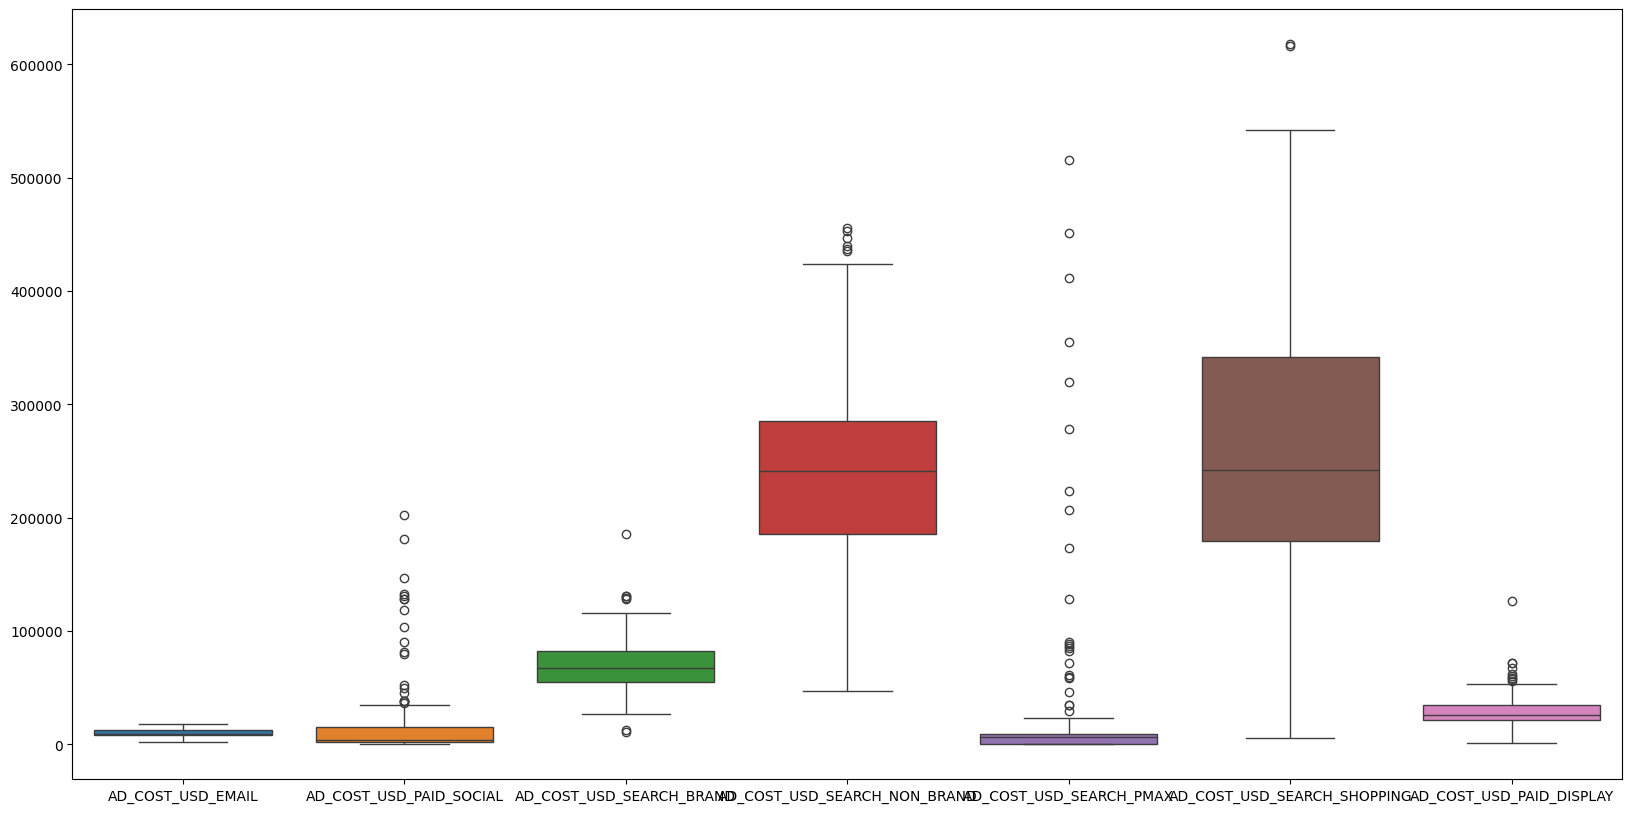

<Axes: >

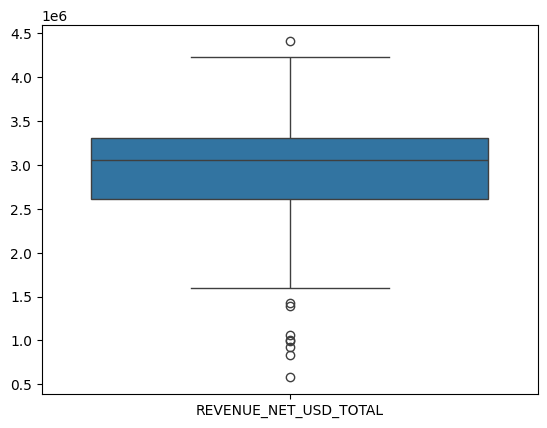

In [ ]:
### Outliers

plt.figure(figsize=(20, 10))
outlier_df_spend = post_spend_df[['AD_COST_USD_EMAIL', 'AD_COST_USD_PAID_SOCIAL', 'AD_COST_USD_SEARCH_BRAND',
       'AD_COST_USD_SEARCH_NON_BRAND', 'AD_COST_USD_SEARCH_PMAX',
       'AD_COST_USD_SEARCH_SHOPPING', 'AD_COST_USD_PAID_DISPLAY']]

outlier_df_revenue = post_spend_df[['REVENUE_NET_USD_TOTAL']]

sns.boxplot(data = outlier_df_spend)
plt.show()
sns.boxplot(data = outlier_df_revenue)

# weekly_df['AD_COST_USD_SEARCH_PMAX'].describe()

In [ ]:
### Share of spend analysis - to set priors

df_spend = weekly_df[['AD_COST_USD_CRITEO_PROSPECTING', 'AD_COST_USD_CRITEO_REMARKETING',
       'AD_COST_USD_EMAIL', 'AD_COST_USD_FACEBOOK_ASC',
       'AD_COST_USD_FACEBOOK_PROSP', 'AD_COST_USD_FACEBOOK_REMARKETING',
       'AD_COST_USD_FACEBOOK_RETENTION', 'AD_COST_USD_GOOGLE_REMARKETING', 'AD_COST_USD_SEARCH_BRAND',
       'AD_COST_USD_SEARCH_NON_BRAND', 'AD_COST_USD_SEARCH_PMAX',
       'AD_COST_USD_SEARCH_SHOPPING']]

df_spend['total_spend'] = df_spend.sum(axis=1)
df_spend.describe()

<Axes: >

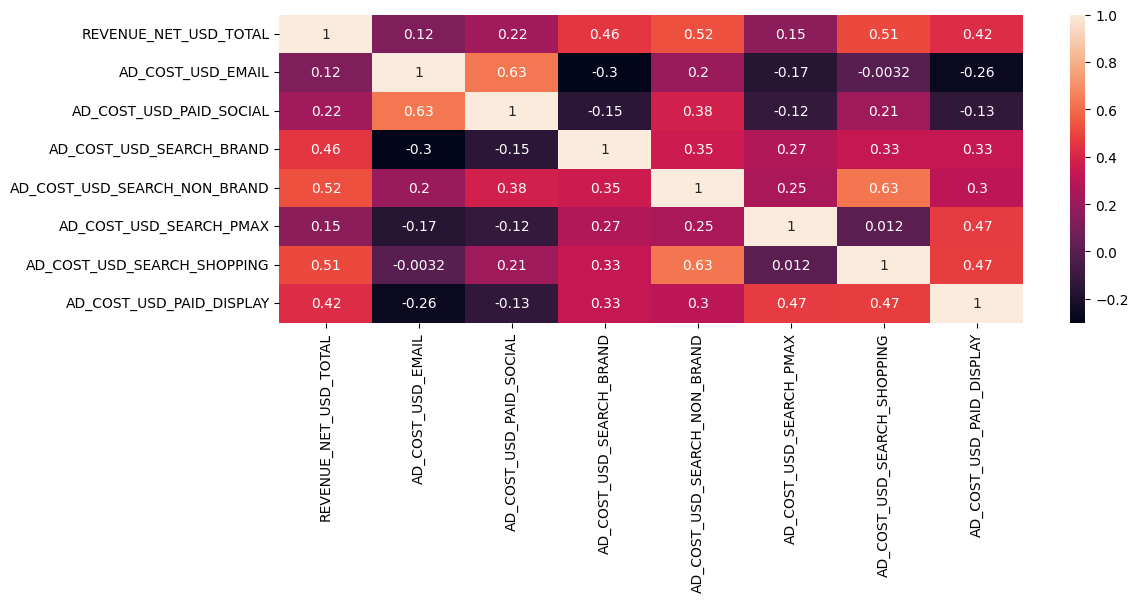

In [ ]:
### Correlation

plt.figure(figsize=(12, 4))

# correlation of columns
corr_df = post_spend_df[['REVENUE_NET_USD_TOTAL',
       'AD_COST_USD_EMAIL', 'AD_COST_USD_PAID_SOCIAL', 'AD_COST_USD_SEARCH_BRAND',
       'AD_COST_USD_SEARCH_NON_BRAND', 'AD_COST_USD_SEARCH_PMAX',
       'AD_COST_USD_SEARCH_SHOPPING', 'AD_COST_USD_PAID_DISPLAY']]


sns.heatmap(corr_df.corr(),annot=True)

In [ ]:
# VIF may help

X = corr_df.drop(columns=['REVENUE_NET_USD_TOTAL'])
import statsmodels.api as sm
X = sm.add_constant(X)


vif_df = pd.DataFrame()
vif_df['feature'] = X.columns

vif_df['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_df)

#### VIF <5 so good to go

                        feature        VIF
0                         const  45.046818
1             AD_COST_USD_EMAIL   1.891596
2       AD_COST_USD_PAID_SOCIAL   1.947952
3      AD_COST_USD_SEARCH_BRAND   1.429385
4  AD_COST_USD_SEARCH_NON_BRAND   2.339312
5       AD_COST_USD_SEARCH_PMAX   1.635241
6   AD_COST_USD_SEARCH_SHOPPING   2.422520
7      AD_COST_USD_PAID_DISPLAY   1.934644


In [ ]:
### Seasonal decomposition

seasonal_df = post_spend_df

seasonal_df = seasonal_df.set_index('DATE').sort_index()

# additive decomposition
# period=52 for weekly data assuming an annual cycle
result = seasonal_decompose(seasonal_df['REVENUE_NET_USD_TOTAL'], model='additive', period=52)

# Create subplots
fig = make_subplots(rows=3, cols=1, shared_xaxes=False, subplot_titles=["Trend (Baseline Growth)","Seasonality (Weekly Patterns)",
        "Residuals (Unexplained Noise)"])

# Trend
fig.add_trace(go.Scatter(x=seasonal_df.index, y=result.trend,mode='lines',name='Trend'),row=1, col=1)

# Seasonal
fig.add_trace(go.Scatter(x=seasonal_df.index, y=result.seasonal,mode='lines',name='Seasonality'),row=2, col=1)


# Residuals
fig.add_trace(go.Scatter(x=seasonal_df.index, y=result.resid,mode='lines',name='Residuals'),row=3, col=1)

fig.update_layout(height=800,title="Time Series Decomposition",showlegend=False)

fig.show()


# Create total spend
post_spend_df['Total_spend'] = (post_spend_df['AD_COST_USD_EMAIL'] + post_spend_df['AD_COST_USD_PAID_SOCIAL'] +
    post_spend_df['AD_COST_USD_SEARCH_BRAND'] + post_spend_df['AD_COST_USD_SEARCH_NON_BRAND'] + post_spend_df['AD_COST_USD_SEARCH_PMAX'] +
    post_spend_df['AD_COST_USD_SEARCH_SHOPPING'] +  post_spend_df['AD_COST_USD_PAID_DISPLAY'])

fig = go.Figure()

fig = make_subplots(specs=[[{"secondary_y": True}]])
# Revenue
fig.add_trace( go.Scatter(x=post_spend_df['DATE'],y=post_spend_df['REVENUE_NET_USD_TOTAL'],mode='lines',name='Revenue'))
fig.add_trace( go.Scatter(x=post_spend_df['DATE'],y=post_spend_df['Total_spend'],mode='lines',name='Spend'),secondary_y=True)


fig.update_layout(title="Revenue vs Spend (Dual Axis)")
fig.show()


In [ ]:
### ROAS EDA

df_roas=pd.read_csv('MMM_ROAS.csv')

df_roas_paid_social = df_roas[df_roas['AD_COST_USD_PAID_SOCIAL']!=0]


df_roas_paid_social['ROAS_EMAIL'] = df_roas_paid_social['REVENUE_NET_USD_EMAIL']/df_roas_paid_social['AD_COST_USD_EMAIL']
df_roas_paid_social['ROAS_SOCIAL'] = df_roas_paid_social['REVENUE_NET__USD_PAID_SOCIAL']/df_roas_paid_social['AD_COST_USD_PAID_SOCIAL']
df_roas_paid_social['ROAS_BRAND'] = df_roas_paid_social['REVENUE_NET_USD_SEARCH_BRAND']/df_roas_paid_social['AD_COST_USD_SEARCH_BRAND']
df_roas_paid_social['ROAS_NBRAND'] = df_roas_paid_social['REVENUE_NET_USD_SEARCH_NON_BRAND']/df_roas_paid_social['AD_COST_USD_SEARCH_NON_BRAND']
df_roas_paid_social['ROAS_SHOPPING'] = df_roas_paid_social['REVENUE_NET_USD_SEARCH_SHOPPING']/df_roas_paid_social['AD_COST_USD_SEARCH_SHOPPING']


df_roas_paid_social.describe()

# assume pmax about 1.5 since data is sparse

/tmp/ipykernel_2621/1658365655.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_2621/1658365655.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_2621/1658365655.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_262

,REVENUE_NET_USD_TOTAL,AD_COST_USD_PAID_DISPLAY,AD_COST_USD_EMAIL,AD_COST_USD_PAID_SOCIAL,AD_COST_USD_SEARCH_BRAND,AD_COST_USD_SEARCH_NON_BRAND,AD_COST_USD_SEARCH_SHOPPING,AD_IMPRESSIONS_PAID_DISPLAY,REVENUE_NET_USD_PAID_DISPLAY,REVENUE_NET_USD_EMAIL,REVENUE_NET__USD_PAID_SOCIAL,REVENUE_NET_USD_SEARCH_BRAND,REVENUE_NET_USD_SEARCH_NON_BRAND,REVENUE_NET_USD_SEARCH_SHOPPING,ROAS_EMAIL,ROAS_SOCIAL,ROAS_BRAND,ROAS_NBRAND,ROAS_SHOPPING
count,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000,9.310000e+02,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000
mean,420494.929108,4070.103115,1500.556391,4036.557465,9738.408163,34532.618690,36795.914071,1.101779e+06,2871.952739,37824.984962,1615.889366,17570.193340,16693.603652,14218.233083,26.752061,1.726339,1.998983,0.503378,0.548279
std,243141.161279,3084.008698,859.260617,24148.015628,6079.863200,16834.137712,21980.747785,1.088710e+06,2020.328447,21164.787277,1540.061045,10187.216922,9466.291830,7462.164907,11.956421,6.476365,1.053190,0.299833,1.185202
min,0.000000,0.000000,110.000000,13.000000,794.000000,3310.000000,614.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,111320.500000,2257.500000,686.000000,469.000000,4177.000000,20773.000000,20832.000000,4.791685e+05,1430.000000,16865.000000,350.000000,8313.000000,8146.500000,8665.000000,19.362289,0.379640,1.388934,0.354757,0.306334
50%,513438.000000,3752.000000,1474.000000,1034.000000,9584.000000,33862.000000,33348.000000,8.927940e+05,2452.000000,40982.000000,1090.000000,17200.000000,16190.000000,12828.000000,24.807065,0.654959,1.848825,0.456244,0.386041
75%,617620.500000,5283.000000,2030.000000,3092.000000,13417.000000,46164.000000,49562.000000,1.413030e+06,3898.000000,53130.000000,2609.000000,25093.500000,23209.500000,18671.500000,32.256950,1.106057,2.395892,0.601895,0.498063
max,917218.000000,52258.000000,5674.000000,722027.000000,45578.000000,96552.000000,142712.000000,1.813604e+07,14458.000000,121820.000000,10024.000000,49558.000000,49971.000000,45507.000000,154.699346,144.714286,15.857849,5.535580,20.413522


### Saturation EDA

for satruation(hill) priors we can look at the point where the rev vs spend curve starts flattening and see its ratio wrt the spend mean of the channel. this is the number we set as prior.

for slope if curve is smooth set slope as 1 else 2

In [ ]:
# remove some outliers
# df_roas = df_roas[df_roas['AD_COST_USD_PAID_SOCIAL']<700000]


fig = px.scatter(
    df_roas,
    x='AD_COST_USD_EMAIL',
    y='REVENUE_NET_USD_EMAIL',
    trendline='lowess'
)

fig.show()

df_roas['AD_COST_USD_EMAIL'].median()

# EMAIL --peaks at 1.4k, --mean 1.4 --conc point = 1--smooth slope =1
# SOCIAL --peaks at 3k, --mean 600 --conc point = 5 --smooth slope =1
# SEARCH_BRAND --peaks at 15k, --mean 10k --conc point = 1.5 --smooth slope =1
# NBRAND --peaks at 40k, --mean 35K --conc point = 1.2 --smooth slope =1
# SHOPPING --peaks at 70k, --mean 35K --conc point = 2--smooth slope =1



1420.0

### Model Building

In [ ]:
# model_df = weekly_df.drop(columns='Total_spend')
model_df = weekly_df

# Convert all numeric columns to float64 to ensure type consistency with Meridian
for col in model_df.select_dtypes(include=['number']).columns:
    model_df[col] = model_df[col].astype(np.float32)

model_df.columns

Index(['DATE', 'REVENUE_NET_USD_TOTAL', 'AD_COST_USD_EMAIL',
       'AD_COST_USD_PAID_SOCIAL', 'AD_COST_USD_SEARCH_BRAND',
       'AD_COST_USD_SEARCH_NON_BRAND', 'AD_COST_USD_SEARCH_PMAX',
       'AD_COST_USD_SEARCH_SHOPPING', 'AD_COST_USD_PAID_DISPLAY', 'EMAIL_OPEN',
       'AD_IMPRESSIONS_PAID_SOCIAL', 'AD_CLICKS_SEARCH_BRAND',
       'AD_IMPRESSIONS_SEARCH_NON_BRAND', 'AD_IMPRESSIONS_SEARCH_PMAX',
       'AD_IMPRESSIONS_SEARCH_SHOPPING', 'AD_IMPRESSIONS_USD_PAID_DISPLAY',
       'SESSIONS_ORGANIC', 'is_off_season'],
      dtype='object')

In [ ]:
# Data builder to align the data to meridian template
builder = data_frame_input_data_builder.DataFrameInputDataBuilder(
    kpi_type='revenue',
    default_kpi_column='REVENUE_NET_USD_TOTAL'
)
builder = (
    builder.with_kpi(model_df, time_col='DATE')
    .with_controls(
        model_df, control_cols=["SESSIONS_ORGANIC",'is_off_season'], time_col='DATE'
    )
)

impression_channels = ['EMAIL_OPEN','AD_IMPRESSIONS_PAID_SOCIAL', 'AD_CLICKS_SEARCH_BRAND', 'AD_IMPRESSIONS_SEARCH_NON_BRAND',
       'AD_IMPRESSIONS_SEARCH_SHOPPING', 'AD_IMPRESSIONS_USD_PAID_DISPLAY']

spend_channels = ['AD_COST_USD_EMAIL', 'AD_COST_USD_PAID_SOCIAL', 'AD_COST_USD_SEARCH_BRAND','AD_COST_USD_SEARCH_NON_BRAND',
       'AD_COST_USD_SEARCH_SHOPPING', 'AD_COST_USD_PAID_DISPLAY']

name_channels = ['EMAIL','PAID_SOCIAL', 'SEARCH_BRAND', 'SEARCH_NON_BRAND', 'SEARCH_SHOPPING', 'PAID_DISPLAY']

builder = builder.with_media(
    model_df,
    media_cols=impression_channels,
    media_spend_cols=spend_channels,
    media_channels=name_channels,
    time_col='DATE'
)

data = builder.build()

print(data.media.shape)

(1, 166, 6)


/usr/local/lib/python3.12/dist-packages/meridian/data/input_data.py:517: UserWarning:

Revenue from the `kpi` data is used when `kpi_type`=`revenue`. `revenue_per_kpi` is ignored.



In [ ]:
#holdout data for train test split

#number of weeks
total_weeks = model_df['DATE'].nunique()

#hold out weeks - last 20% weeks

holdout_weeks = int(total_weeks * 0.4)


# Create an array: first 100 weeks are False, last 4 are True
holdout_id = np.concatenate([
    np.zeros(total_weeks - holdout_weeks, dtype=bool),
    np.ones(holdout_weeks, dtype=bool)
])

# holdout_id

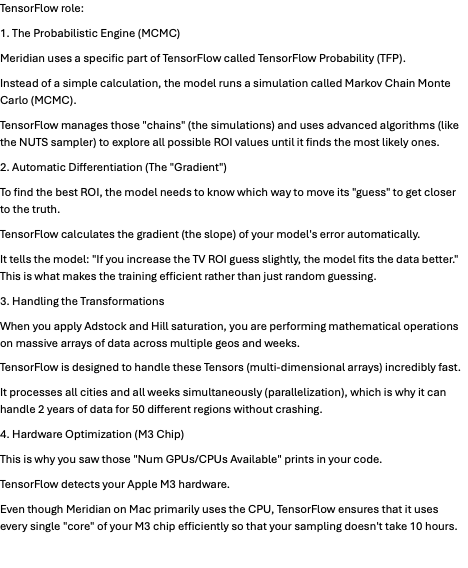

In [ ]:
# Define priors using float32 to match the dataframe casting

#roi priors
roi_means = [np.log(4.0), np.log(1.0), np.log(2.5), np.log(2.0), np.log(2.0), np.log(1.0)]
roi_scales = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
roi_priors_vectorized = tfp.distributions.LogNormal(loc=tf.constant(roi_means, dtype=tf.float32), scale=tf.constant(roi_scales, dtype=tf.float32))

#ad-stock priors
alpha_a = [2.0, 2.0, 2.0, 2.0, 2.0, 1.0]
alpha_b = [2.0, 2.0, 2.0, 2.0, 2.0, 3.0]
alpha_priors_vectorized = tfp.distributions.Beta(concentration1=tf.constant(alpha_a, dtype=tf.float32), concentration0=tf.constant(alpha_b, dtype=tf.float32))

#saturation priors[ec=effective concentration-->place of flattening,slope = how fast we reach ec from 0]
ec_priors = [np.log(1.0), np.log(5.0), np.log(1.5), np.log(1.2), np.log(2.0), np.log(2.0)]
ec_scales = [0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
ec_priors_vectorized = tfp.distributions.LogNormal(loc=tf.constant(ec_priors, dtype=tf.float32), scale=tf.constant(ec_scales, dtype=tf.float32))

slope_priors = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
slope_scales = [0.2, 0.2, 0.2, 0.2, 0.2, 0.2]
slope_priors_vectorized = tfp.distributions.LogNormal(loc=tf.constant(slope_priors, dtype=tf.float32), scale=tf.constant(slope_scales, dtype=tf.float32))

In [ ]:
# Remove tfp.distributions.Independent to fix broadcasting issues in National models
priors_dict = prior_distribution.PriorDistribution(
    roi_m=roi_priors_vectorized,
    alpha_m=alpha_priors_vectorized,
    ec_m=ec_priors_vectorized,
    slope_m=slope_priors_vectorized
)


In [ ]:
model_spec = spec.ModelSpec(
    prior=priors_dict,
    holdout_id=holdout_id,
    enable_aks=True,
    hill_before_adstock=False
)

In [ ]:
mmm = model.Meridian(input_data=data, model_spec=model_spec)

/usr/local/lib/python3.12/dist-packages/meridian/model/model.py:75: UserWarning:

In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.



In [ ]:
%%time
mmm.sample_prior(500)
mmm.sample_posterior(
    n_chains=10, n_adapt=2000, n_burnin=500, n_keep=1000, seed=0
)

/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning:

Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).

/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning:

Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).

/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning:

Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).

/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning:

Hierarchical distribution parameters must be deterministically zero for national models. eta_om has been automatically set to Deterministic(0).

/usr/local/lib/pytho

CPU times: user 12min 56s, sys: 16.1 s, total: 13min 12s
Wall time: 13min 12s


/usr/local/lib/python3.12/dist-packages/arviz/data/inference_data.py:157: UserWarning:

trace group is not defined in the InferenceData scheme

/usr/local/lib/python3.12/dist-packages/arviz/data/inference_data.py:1647: UserWarning:

trace group is not defined in the InferenceData scheme



### Post model

In [ ]:
#save file to avoid running model again
import pickle

# Define your file path
save_path = 'my_meridian_model.pkl'

# Using standard pickle to save the model object as a fallback
try:
    with open(save_path, 'wb') as f:
        pickle.dump(mmm, f)
    print(f"Model successfully saved to {save_path}")
except Exception as e:
    print(f"Failed to save model: {e}")

Model successfully saved to my_meridian_model.pkl


In [ ]:
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.plot_rhat_boxplot()

alt.LayerChart(...)

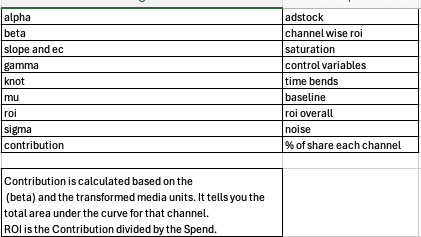

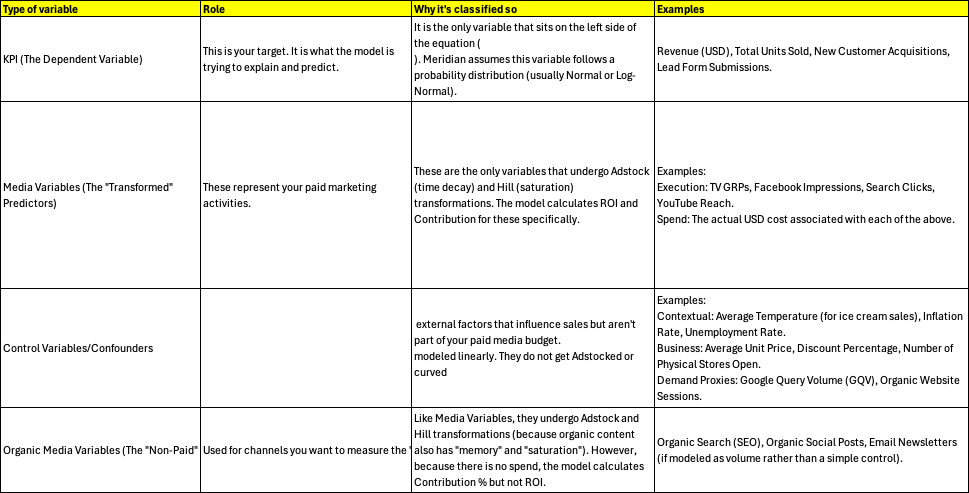

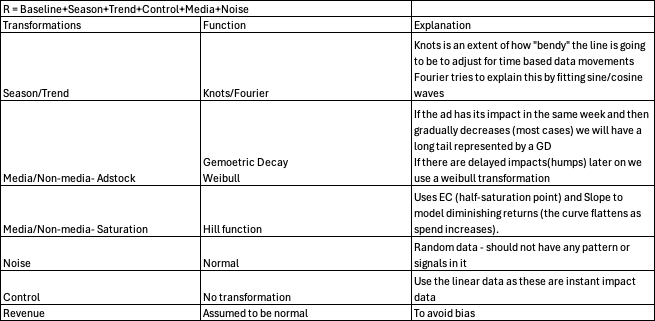

In [ ]:
model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:693: UserWarning:

The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.



alt.LayerChart(...)

In [ ]:
mmm_summarizer = summarizer.Summarizer(mmm)

filepath = '/'
mmm_summarizer.output_model_results_summary(
    'summary_output.html', filepath
)

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:693: UserWarning:

The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:693: UserWarning:

The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning:

invalid value encountered in subtract

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:3352: UserWarning:

Effectiveness is not reported because it does not have a clear interpretation by time period.

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1031: UserWarning:

Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.



In [ ]:
IPython.display.HTML(filename='/summary_output.html')

Dataset,R-squared,MAPE,wMAPE
Training Data,0.96,4%,4%
Testing Data,-0.57,17%,17%
All Data,0.89,5%,5%


### budget optimization

In [ ]:
%%time
budget_optimizer = optimizer.BudgetOptimizer(mmm)
optimization_results = budget_optimizer.optimize()

CPU times: user 2min 28s, sys: 1.19 s, total: 2min 29s
Wall time: 1min 55s


In [ ]:
filepath = '/'
optimization_results.output_optimization_summary(
    'optimization_output.html', filepath
)

In [ ]:
IPython.display.HTML(filename='/optimization_output.html')

Channel,Non-optimized spend,Optimized spend
SEARCH_NON_BRAND,39%,45%
SEARCH_SHOPPING,41%,33%
SEARCH_BRAND,11%,14%
PAID_DISPLAY,5%,3%
EMAIL,2%,2%
PAID_SOCIAL,3%,2%
